In [4]:
import numpy as np 
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch_geometric

from torch_geometric.data import Data
from scipy.optimize import curve_fit

print(torch.version.cuda)
print(torch.__version__)
print(torch_geometric.__version__)

11.8
2.7.0+cu118
2.6.1


In [23]:
data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/test_batches/test_batch.npz")
print(data.files)
init_energies = data["init_energies"]
print(data["init_energies"].shape)
print(init_energies)

['inputIdx', 'outputIdx', 'currents', 'inputs', 'acc_xy', 'don_xy', 'jagged_lengths', 'neighbour_indices', 'init_energies']
(208,)
[ 1.60647195e+00  2.42052076e+00  1.47770508e+00  4.01093166e-01
 -3.53797682e-01  2.85096774e+00  3.89336802e-01  1.64747413e+00
  7.16736670e-01  1.99696026e+00  9.20783265e-01 -3.42678206e-01
 -6.59471212e-02 -1.30589205e+00 -1.95670465e+00  2.61514697e-01
 -1.01597059e+00  1.70299345e-01  3.75385767e-01 -5.01329172e-01
  2.24311867e-01  1.11121522e+00  4.81544023e+00 -4.24722586e+00
 -1.39125365e+00  1.78677869e+00 -4.71759743e-01  1.53449907e+00
 -8.89761288e+00  3.56635023e-01 -9.24567796e-01  1.50592881e+00
  1.12496574e+00 -3.79226724e+00 -5.10624777e-01  2.35201870e+00
  2.17214747e+00 -2.37708811e-01  2.39791634e-02 -6.79630592e-01
 -6.33825957e-01  1.85717913e-01 -7.93612165e-02  1.69977967e-01
 -8.51582009e-01 -7.84190433e-01 -1.80182255e+00 -7.01791174e-01
 -4.23206296e+00 -1.54017470e+00  2.17337883e+00 -1.08912509e+00
  1.50497361e+00 -1.4638

In [53]:
print(data["jagged_lengths"].shape)
print(data["neighbour_indices"].shape)

jagged_lengths = data["jagged_lengths"]
neighbour_indices = data["neighbour_indices"]

#print(jagged_lengths)
#print(f"last_index: {neighbour_indices[-1]}")

#print(data["acc_xy"][0])

neighbours = np.zeros(shape=(208, 208))

"""Convert jagged_arrays back to (n x n)"""
for k in range(jagged_lengths.shape[0]-1):
    jagged_length = jagged_lengths[k+1] - jagged_lengths[k]
    #print(f"jagged_length: {jagged_length}")
    for idx in neighbour_indices[jagged_lengths[k]:jagged_lengths[k+1]]:
        #print(idx)
        neighbours[k][idx] = 1

(209,)
(5374,)


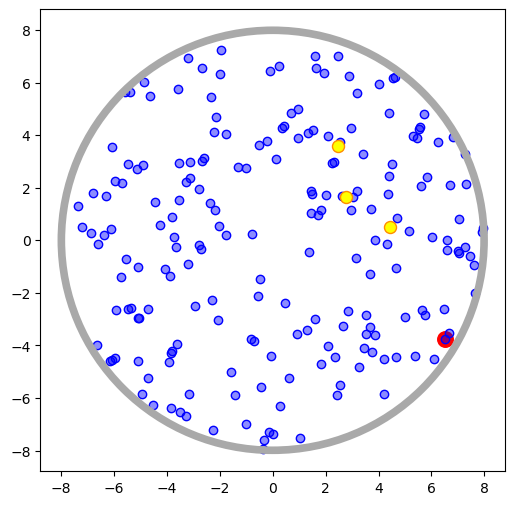

In [24]:
radius = 150.0
n_a = 200
n_d = 3
R = np.sqrt(np.pi*radius**2 / 200)
scaled_radius = radius / R

face_color_acc = (0, 0, 1, 0.45)
edge_color_acc = (0, 0, 1, 1.0)

#idx = np.random.randint(low=0, high=100)
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(*data["acc_xy"].T, edgecolor=edge_color_acc, facecolor=face_color_acc, zorder=3)
ax.scatter(*data["don_xy"].T, s=75, edgecolor="darkorange", facecolor="yellow", zorder=3)
ax.scatter(6.510259, -3.75068, c="r", s=125)
circle = patches.Circle((0,0), radius=scaled_radius + 1e-2, fill=None, edgecolor="darkgray", lw=5.5, zorder=4)
ax.add_patch(circle)

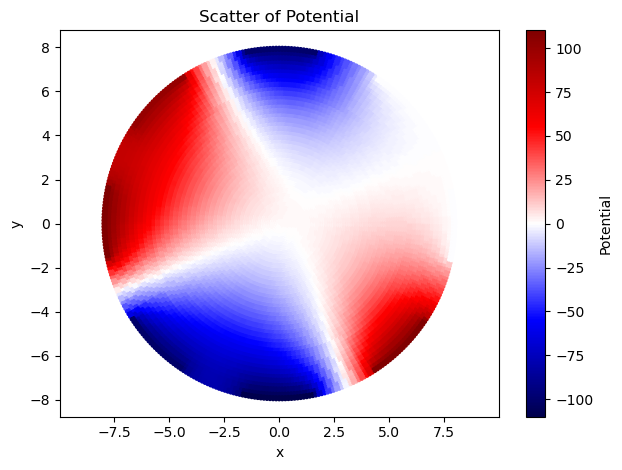

In [59]:
potential = np.loadtxt("../../phi_0.txt")
x = potential[:, 0]
y = potential[:, 1]
phi = potential[:, 2]


plt.figure()
sc = plt.scatter(x, y, c=phi, s=5, marker='o', cmap="seismic")
plt.colorbar(sc, label="Potential")
plt.axis("equal")
plt.title("Scatter of Potential")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.savefig("potential_scatter.png", dpi=150)
plt.show()

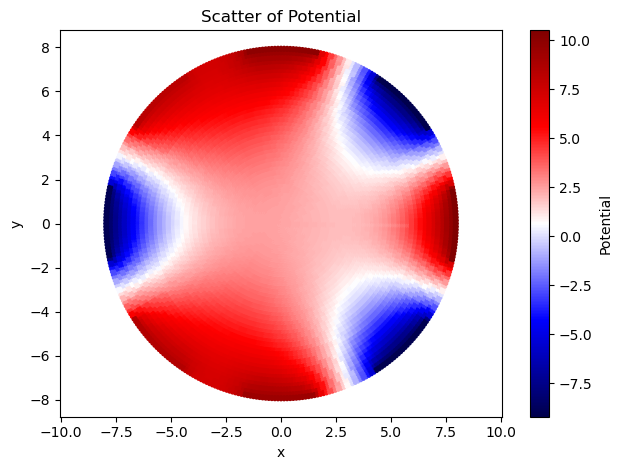

In [60]:
potential = np.loadtxt("../../phi_1.txt")
x = potential[:, 0]
y = potential[:, 1]
phi = potential[:, 2]


plt.figure()
sc = plt.scatter(x, y, c=phi, s=5, marker='o', cmap="seismic")
plt.colorbar(sc, label="Potential")
plt.axis("equal")
plt.title("Scatter of Potential")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.savefig("potential_scatter.png", dpi=150)
plt.show()

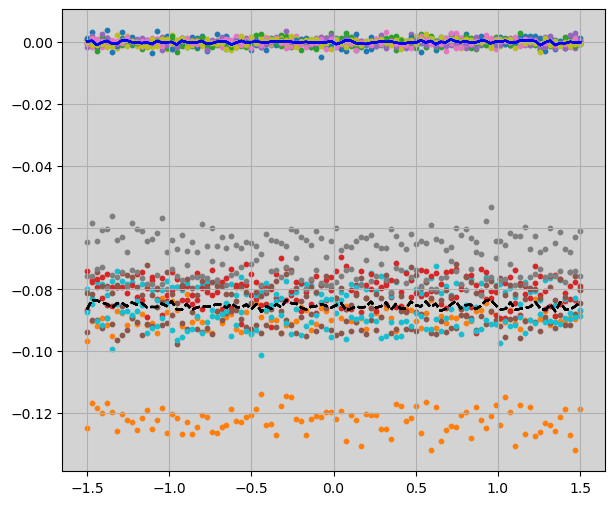

In [58]:
data_1 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/test_folder/test_file_31.npz")
data_2 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/test_folder/test_file_32.npz")

currents_1 = data_1["current"]
currents_2 = data_2["current"]

avg_current_1 = np.mean(currents_1, axis=0)
avg_current_2 = np.mean(currents_2, axis=0) 

vs = np.linspace(-1.5, 1.5, 100)
fig, ax = plt.subplots(figsize=(7, 6))
ax.grid(True)
ax.set_facecolor("lightgray")
for i in range(currents_1.shape[0]):
    ax.scatter(vs, currents_1[i,:], s=10)
    ax.plot(vs, avg_current_1, lw=1.5, c="b")

    ax.scatter(vs, currents_2[i,:], s=10)
    ax.plot(vs, avg_current_2, lw=1.5, c="k", linestyle="--")

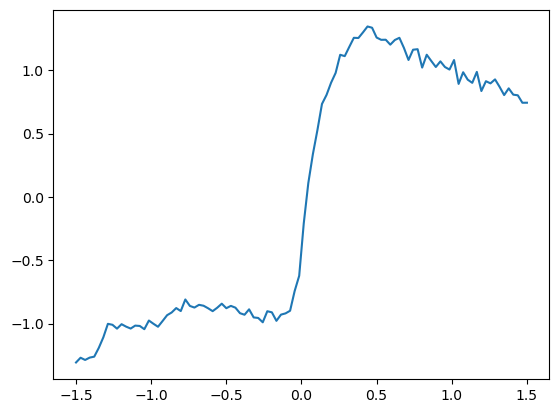

In [82]:
mean = np.mean(avg_current_1)
std = np.std(avg_current_1, ddof=1)

std_curve = (avg_current_1 - mean) / std

plt.plot(vs, std_curve)

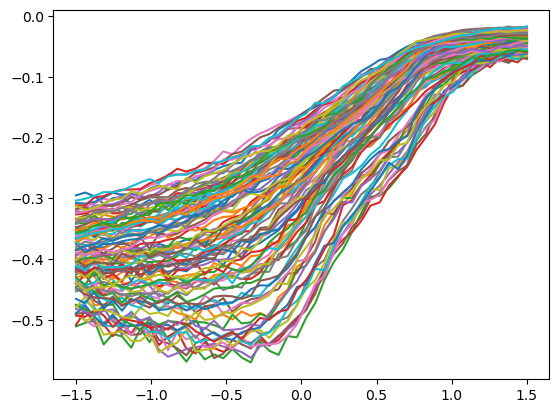

In [16]:
data = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/100_sweep/row_7.npz")
vs = np.linspace(-1.5, 1.5, 50)
n = 100
for i in range(0, 100):
    plt.plot(vs, data["out"][i])

In [ ]:
def sigmoid_fit(v, I_0, I_1, a, V_2):

    out = I_0 + (I_1 - I_0) / (1 + np.exp(-a*(v - V_2)))

    return out

def linear_fit(v, a, b):

    out = a*v + b

    return out

vs = np.linspace(-1.5, 1.5, 50)
n = 100
arr = np.zeros((n, n))

rows = []
for i in range(n):
    data = np.load(f"../../data/100_sweep/row_{i}.npz")
    rows.append(data["out"])
    for j in range(n):
        curve = data["out"][j]
        num_of_points = curve.shape[0]
        fit_params, cov = curve_fit(linear_fit, vs, curve)
        rmse = np.sqrt( np.mean( (curve - linear_fit(vs, fit_params[0], fit_params[1]))**2 ) )
        arr[i][j] = rmse

#flipped_arr = arr[::-1]

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(
    arr,
    extent=[0.01, 0.2,
            77, 200],
    aspect="auto",
    origin="lower",
    cmap="seismic_r"
)

xticks = np.linspace(0.01, 0.2, 5)
yticks = np.linspace(77, 200, 5)
ax.set_xticks(xticks)
ax.set_yticks(yticks)

plt.colorbar(im, ax=ax)

FileNotFoundError: [Errno 2] No such file or directory: '../../data/100_sweep/row_18.npz'

# 1.) Create Batch of I-V curves

In [7]:
from calculate_iv_curve import simulate_iv_curve

batch_size = 200
seed_0 = 420

control_indices = [1, 2, 3, 4, 6, 7]

for i in range(batch_size):

    control_voltages = np.random.uniform(-1.5, 1.5, size=(len(control_indices), ))
    control_voltages_dict = {
        idx: voltage for idx, voltage in zip(control_indices, control_voltages)
    }
    simulate_iv_curve(name=i, seed=i, params=control_voltages_dict)

num_of_curves: 200


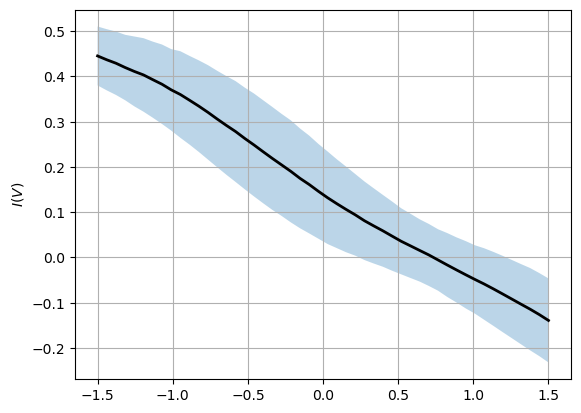

In [12]:
curve_list = []
print(f"num_of_curves: {batch_size}")
for i in range(batch_size):
    _curve = np.load(f"../../data/iv_curves/data_point_{i}.npz")
    curve_list.append(_curve["outputCurrent"])

np.save(file="../../data/batch_200_samples_truncnorm_1/curves_200_1.npy", arr=np.array(curve_list))

iv_curves = np.load(file="../../data/batch_200_samples_truncnorm_1/curves_200_1.npy")
num_of_points = iv_curves[0].shape[0]

mean = np.mean(iv_curves, axis=0)
std_dev = np.std(iv_curves, ddof=1, axis=0)

vs = np.linspace(-1.5, 1.5, iv_curves.shape[1])
plt.plot(vs, mean, lw=2., c='k')
plt.fill_between(vs, mean-std_dev, mean+std_dev, alpha=.3)
plt.ylabel("$I(V)$")
plt.grid(True)

# 2.) Truncated Normal Geometry

7.978845608028652
3.191538243211461
std_scaled: 3.191538243211461


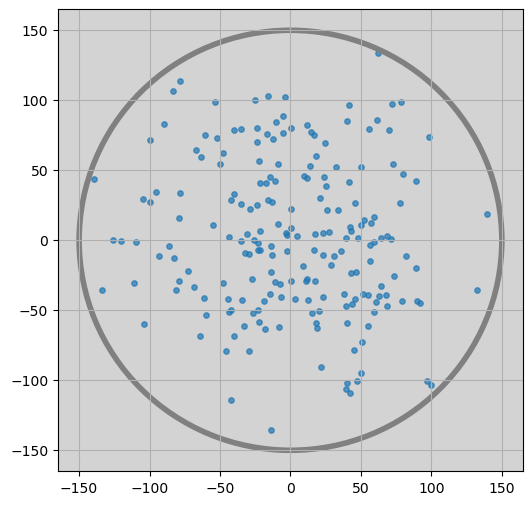

In [9]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

radius = 150.0
n_a = 200
n_d = 3
R = np.sqrt(np.pi*radius**2 / 200)
scaled_radius = radius / R
print(scaled_radius)
print(60. / R)

std_dev = radius / 2.5
std_scaled = std_dev / R
print(f"std_scaled: {std_scaled}")
cov_matrix = (std_dev ** 2) * np.eye(2)

if os.path.isfile("../../configs/acceptor_normal.txt"):
    pass
else:
    file = open("../../configs/acceptor_normal.txt", "x")

acceptor_pos = []

with open("../../configs/acceptor_normal.txt", "w") as f:
    while len(acceptor_pos) < 200:
        X = np.random.multivariate_normal(mean=np.zeros(2), cov=cov_matrix)
        if np.sqrt(X[0]**2 + X[1]**2) <= radius:
            acceptor_pos.append(X)

with open("../../configs/acceptor_normal.txt", "w") as f:
    for _pos in acceptor_pos:
        f.write(f"{_pos[0]}\t{_pos[1]}\n")

acceptors_array = np.array(acceptor_pos)

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(acceptors_array[:,0], acceptors_array[:,1], s=15., alpha=.7)
ax.grid()
ax.set_facecolor("lightgrey")    
boundary = Circle((0, 0), radius=radius, fill=False, edgecolor="gray", lw=4)
ax.add_patch(boundary)


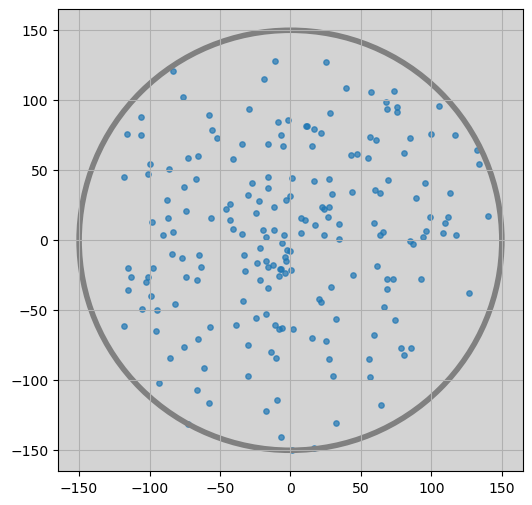

In [12]:
coordinates = []

with open("../../configs/acceptor_normal.txt", "r") as f:
    for _l in f:
        line = _l.strip().split()

        coords = np.array([float(line[0]), float(line[1])])
        coordinates.append(coords)

coordinate_array = np.array(coordinates)

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(coordinate_array[:,0], coordinate_array[:,1], s=15., alpha=.7)
ax.grid()
ax.set_facecolor("lightgrey")    
boundary = Circle((0, 0), radius=radius, fill=False, edgecolor="gray", lw=4)
ax.add_patch(boundary)


['ID', 'inputs', 'outputs']


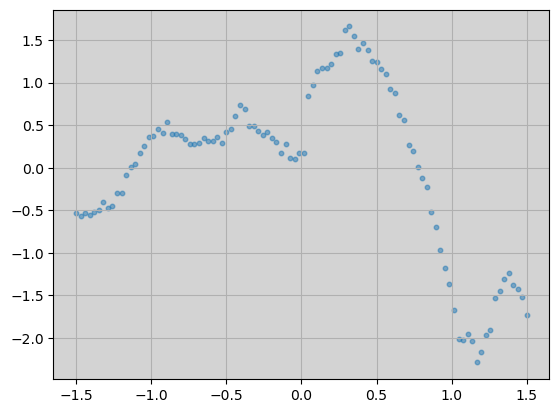

In [91]:
data = np.load("../../data/batch_10002.npz")
inputs = data["inputs"]

print(data.files)
num = len(data["outputs"][0,:])

vs = np.linspace(-1.5, 1.5, num)

plot_kwargs = {
    "s": 10.5,
    "alpha": .5,
}

fig, ax = plt.subplots()

output_mean = np.mean(data["outputs"][0, :])
output_std = np.std(data["outputs"][0, :], ddof=1)
normalized_outputs = (data["outputs"][0, :] - output_mean) / output_std

ax.scatter(vs, normalized_outputs, **plot_kwargs)
ax.grid()
ax.set_facecolor("lightgrey")

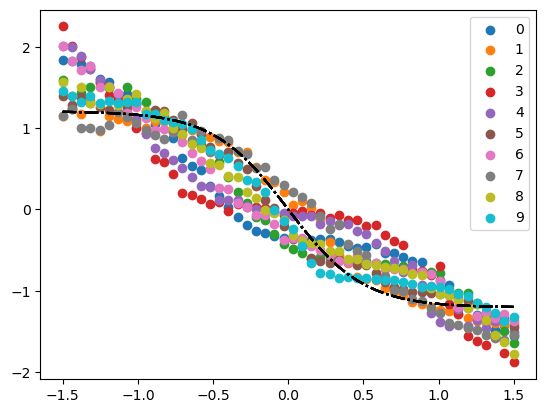

In [132]:
curves = []

num_of_plots = 10
for i in range(num_of_plots):
    data = np.load(f"../../data/trials/data_point_{i}.npz")
    out = data["outputCurrent"]
    out = (out - np.mean(out)) / np.std(out, ddof=1)
    curves.append(out)
vs = np.linspace(-1.5, 1.5, curves[0].shape[0])

def target(x):
    return 1 / (1 + np.exp(4*x))

targets = target(vs)
normalized_targets = (targets - np.mean(targets)) / np.std(targets, ddof=1)

fig, ax = plt.subplots()
for i in range(num_of_plots):
    ax.scatter(vs, curves[i], label=f"{i}")
    ax.plot(vs, normalized_targets, color='k', linestyle="-.")
    plt.legend()

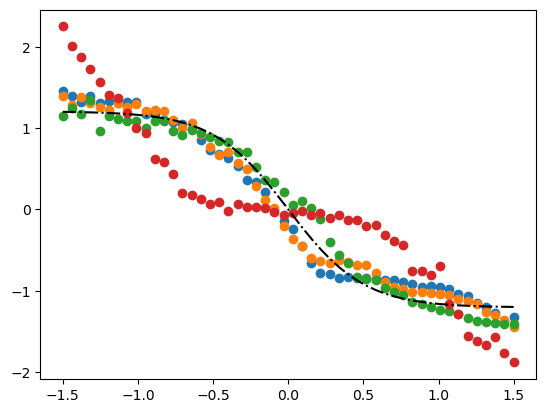

In [137]:
plt.scatter(vs, curves[9])
plt.scatter(vs, curves[5])
plt.scatter(vs, curves[1])
plt.scatter(vs, curves[3])
plt.plot(vs, normalized_targets, color='k', linestyle="-.")